# Trabajo Práctico Nº2 : Filtrado Digital
Curso: R4052  
Profesor: Mariano Llamedo Soria  
Ayudante de TPs: David Moharos  
Jefe de TPs: Cesar Fuoco  
Grupo: 3

Integrantes: Rodríguez Silvosa, Martín; Fabi, Juan Sebastián; Casal Bruno, Sebastián;

Autor Alumno particular: Rodríguez Silvosa, Martín

### Objetivos:
Consolidar los conceptos de los sistemas muestreados mediante el uso de ADC y DACs.
Simular e implementar un filtro digital con el STM NUCLEO-64 
Familiarizarse con el uso de librerías para procesamiento digital de señales.
Medir las partes de la función transferencia H[z] para frecuencias entre 10 Hz y 10 kHz.


### Descripción:

El trabajo práctico tiene como objetivo la implementación de funciones transferencias digitales utilizando como procesador de señales el STM NUCLEO-64.

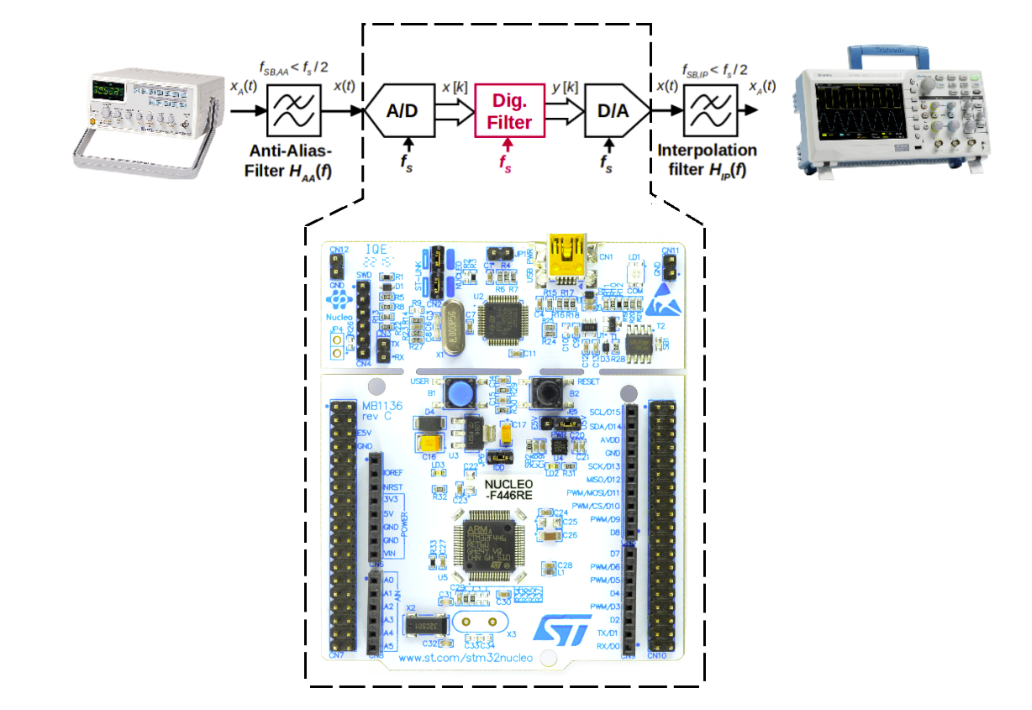

## Previo al Laboratorio:
### Plantillas de diseño:
1. Se implementarán los filtros obtenidos de la Tarea Semanal 9: Laboratorio de filtros digitales.

### Librería CMSIS:
El filtro digital en sí mismo es un algoritmo. En nuestro caso para simplificar la tarea vamos a instanciar funciones de la librería de procesamiento digital de arm cmsis-dsp:

- arm_fir_f32 
- arm_biquad_cascade_df1_f32

Desde la cátedra facilitaremos el código que permite inicializar estas funciones, de tal manera que solo se encarguen de invocarlas correctamente para realizar el filtrado.

- El IDE para trabajar con el mcu es el STM32CubeIDE.

- El workspace del proyecto es proveído por la cátedra.


### Armado del circuito
Para poder ingresar la señal proveniente del generador de funciones correctamente al MCU deberán colocar un filtro Antialias y proporcionar un nivel de continua. Recuerden que se debe ingresar al ADC con una señal entre 0 y 3.3V.  A la salida del DAC bastará solo con replicar el filtro de entrada.

El diseño de estos filtros analógicos es a criterio libre de cada grupo de trabajo.

# Desarrollo
## Implementación de los filtros digitales:

### Simulaciones:

In [1]:
# Inicialización e importación de módulos

# Módulos para Jupyter
import warnings
warnings.filterwarnings('ignore')

# Módulos importantantes
import scipy.signal as sig
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.io as sio
from pytc2.sistemas_lineales import plot_plantilla

# Tamaño de las figuras
fig_sz_x = 14
fig_sz_y = 7

# Tamaño de la tipografía
fig_font_size = 16

plt.rcParams.update({'font.size':fig_font_size})

###
## Señal de ECG registrada a 1 kHz, con contaminación de diversos orígenes.
###

# para listar las variables que hay en el archivo
#io.whosmat('ecg.mat')
#mat_struct = sio.loadmat('ecg.mat')

#ecg_one_lead = mat_struct['ecg_lead']
#ecg_one_lead = ecg_one_lead.flatten()
#cant_muestras = len(ecg_one_lead)

fs = 1000 # Hz
nyq_frec = fs / 2

#### Plantilla de diseño (TS9):

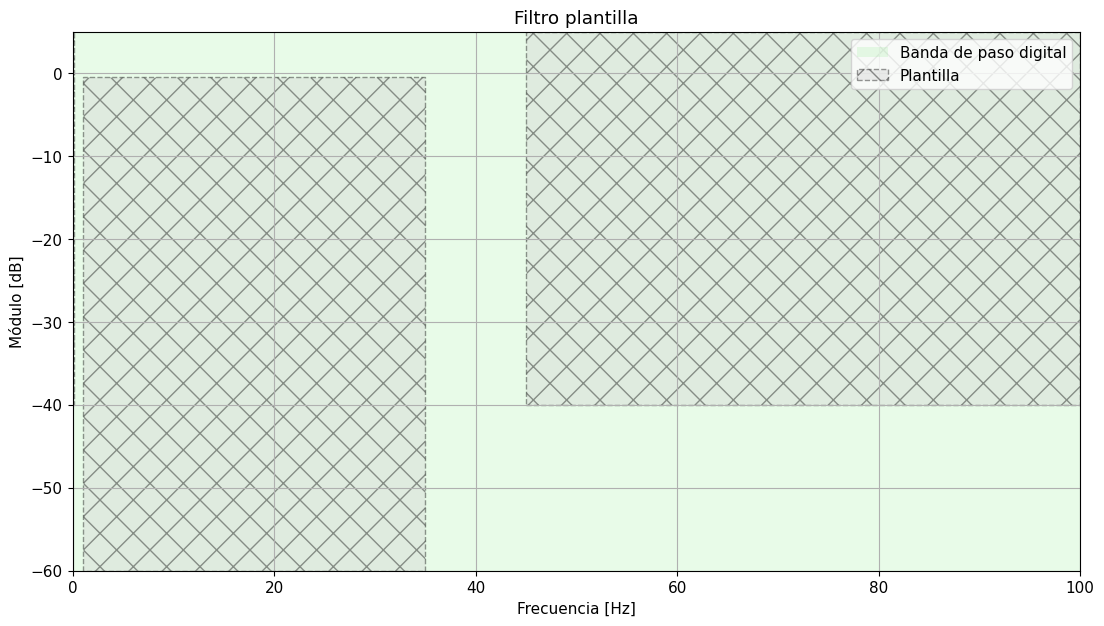

In [7]:
# Plantilla

# filter design
ripple = 0.5 # dB
atenuacion = 40 # dB

ws1 = .1 #Hz
wp1 = 1 #Hz
wp2 = 35.0 #Hz
ws2 = 45.0 #Hz

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.axis([0, 100, -60, 5 ]);

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)


plt.title('Filtro plantilla')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
_ = plt.legend()

#### Filtro IIR:

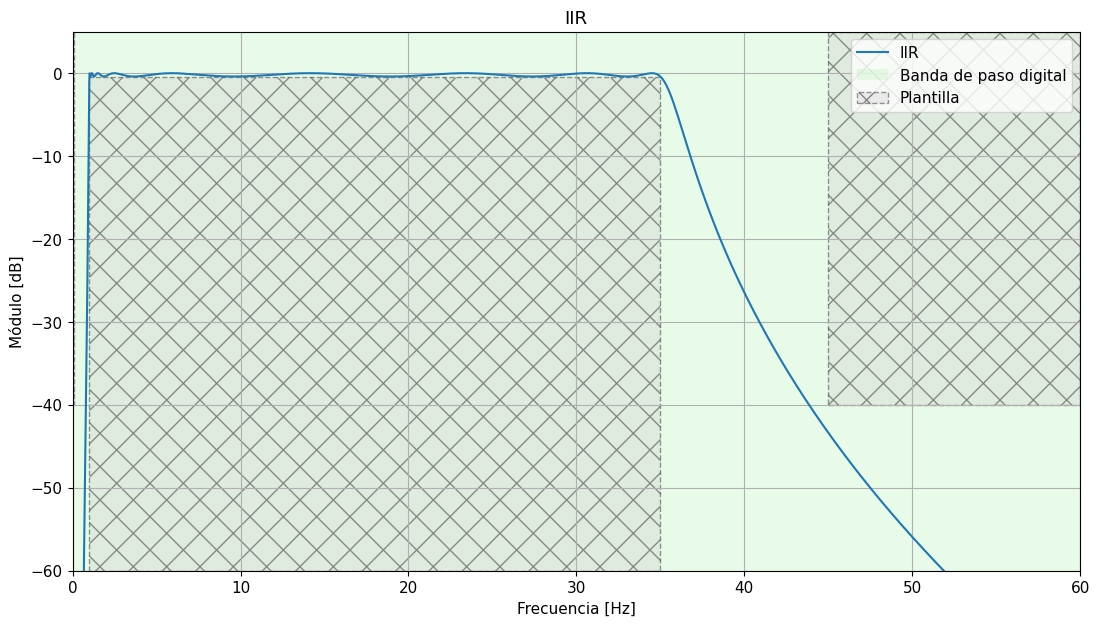

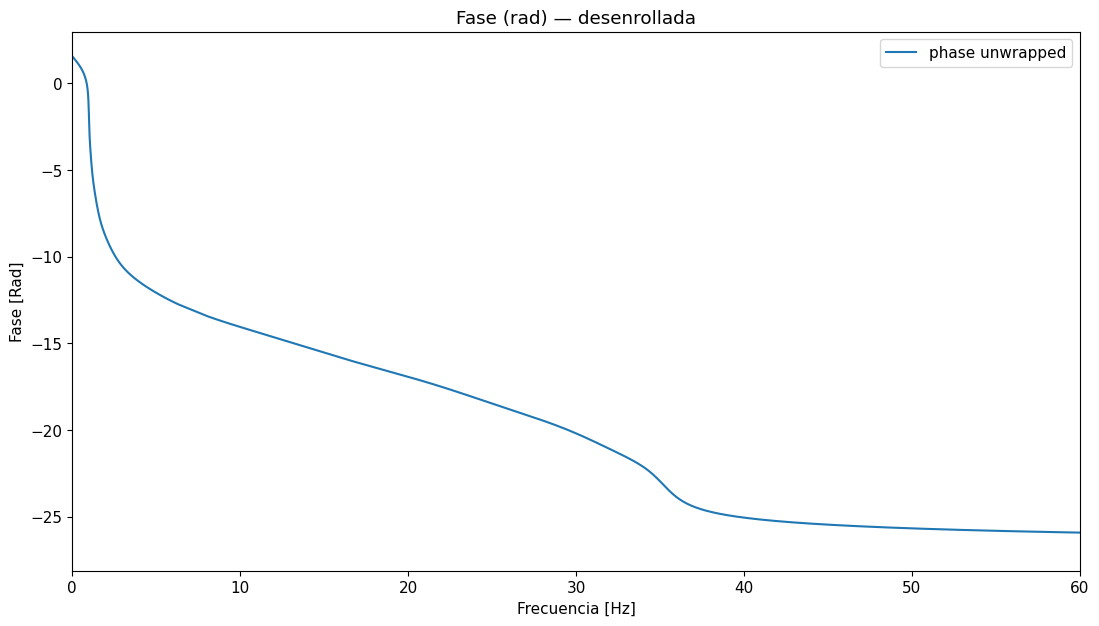

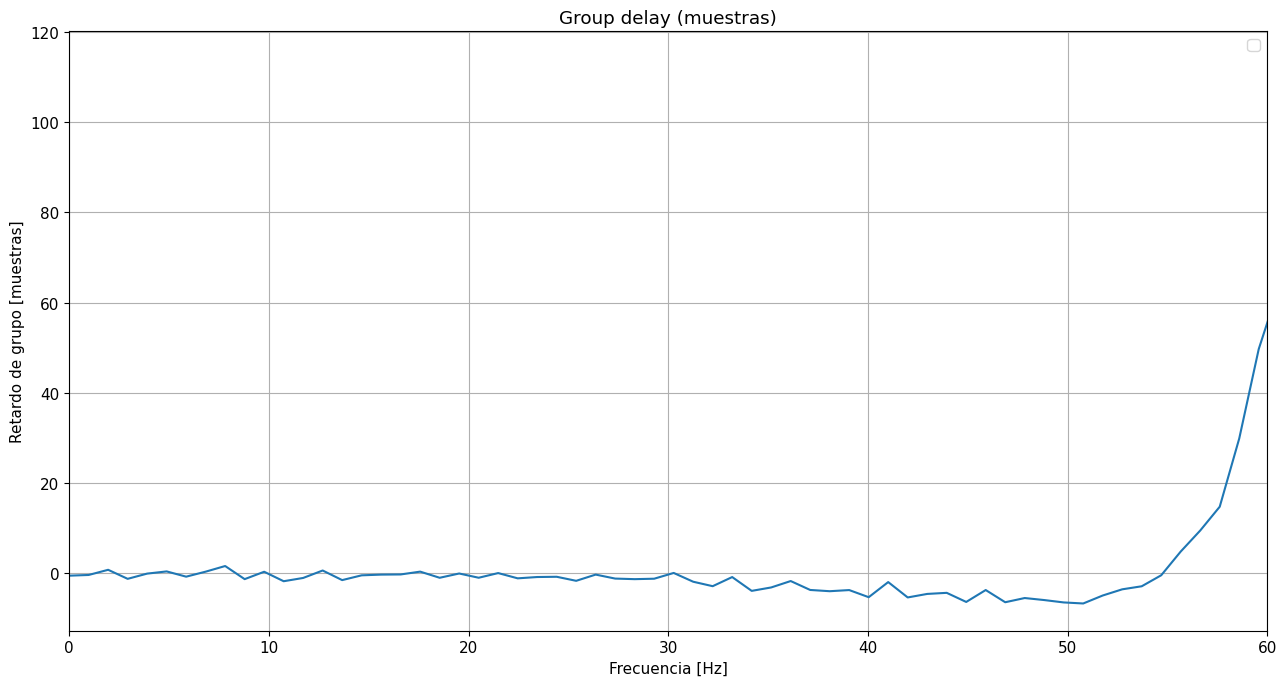

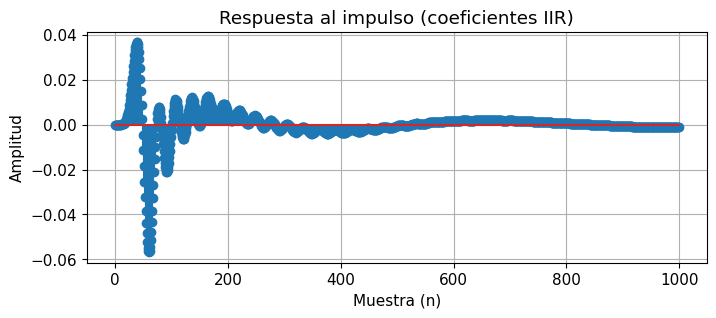

In [8]:
# Variables
ripple_iterado = 0.4 # dB
atenuacion_iterado = 40 # dB

sos_iir = sig.iirdesign(wp=[wp1,wp2],ws=[ws1,ws2],gpass=ripple_iterado, gstop=atenuacion_iterado, output='sos', analog=False, ftype='cheby1', fs = fs)

w_rad  = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000) )
w_rad  = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True) )

w_rad, h_iir = sig.freqz_sos(sos_iir, worN=w_rad, fs = fs)

phase = np.angle(h_iir)
phase_unwrapped = np.unwrap(phase)

#%matplotlib qt

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir)+1e-12), label = 'IIR' )

plt.title('IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 60, -60, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()
plt.show()

b_iir, a_iir = sig.sos2tf(sos_iir)  # convierte SOS a b, a
w_gd, gd = sig.group_delay((b_iir, a_iir), fs=fs)

mag_db = 20 * np.log10(abs(h_iir))

phase = np.angle(h_iir)
phase_unwrapped = np.unwrap(phase)

pb_idx = np.where(mag_db > -40)[0]
if pb_idx.size > 10:
    # ajustar fase_unwrapped vs frecuencia (Hz): phase = -2*pi*f*delay + const
    p = np.polyfit(w_rad[pb_idx], phase_unwrapped[pb_idx], 1)
    slope = p[0]
    est_delay_from_phase = -slope / (2 * np.pi)   # en muestras
else:
    est_delay_from_phase = np.nan

imp = np.zeros(1000)  # tamaño deseado
imp[0] = 1.0
h_iir_imp = sig.sosfilt(sos_iir, imp)

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_rad, phase_unwrapped, label='phase unwrapped')
plt.title('Fase (rad) — desenrollada')

plt.xlabel('Frecuencia [Hz]')
plt.xlim(0, min(0.5*fs, 60))
plt.ylabel('Fase [Rad]')
plt.grid()
#plt.axis([0, 60, -60, 5 ]);
plt.legend()

axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid()
_ = plt.legend()
plt.show()

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_gd, gd)
plt.title('Group delay (muestras)')
plt.xlim(0, min(0.5*fs, 60))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Retardo de grupo [muestras]')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#axes_hdl = plt.gca()
#axes_hdl.legend()
# plt.grid()
# _ = plt.legend()

# Impulso (stem)
plt.figure(figsize=(8,3))
plt.stem(h_iir_imp)
plt.title('Respuesta al impulso (coeficientes IIR)')
plt.xlabel("Muestra (n)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

#### Filtro FIR:

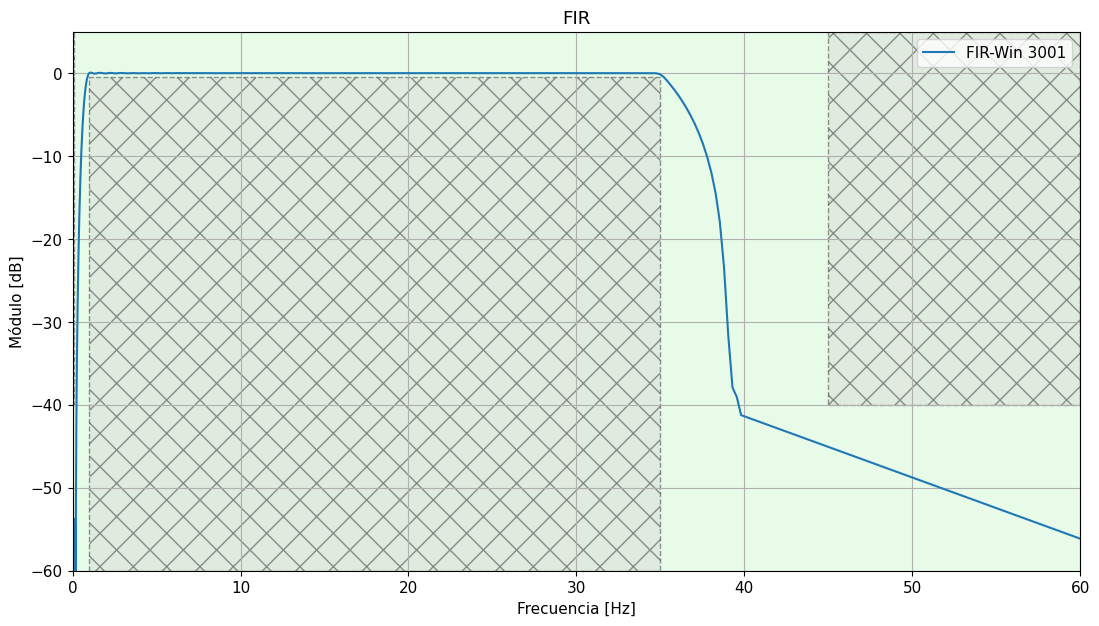

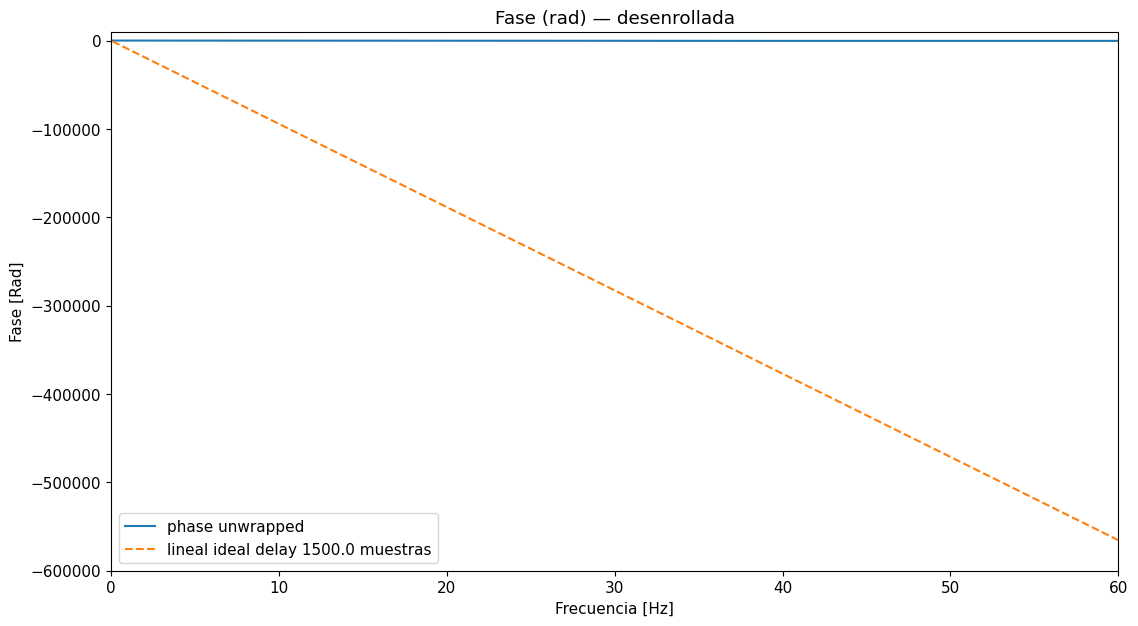

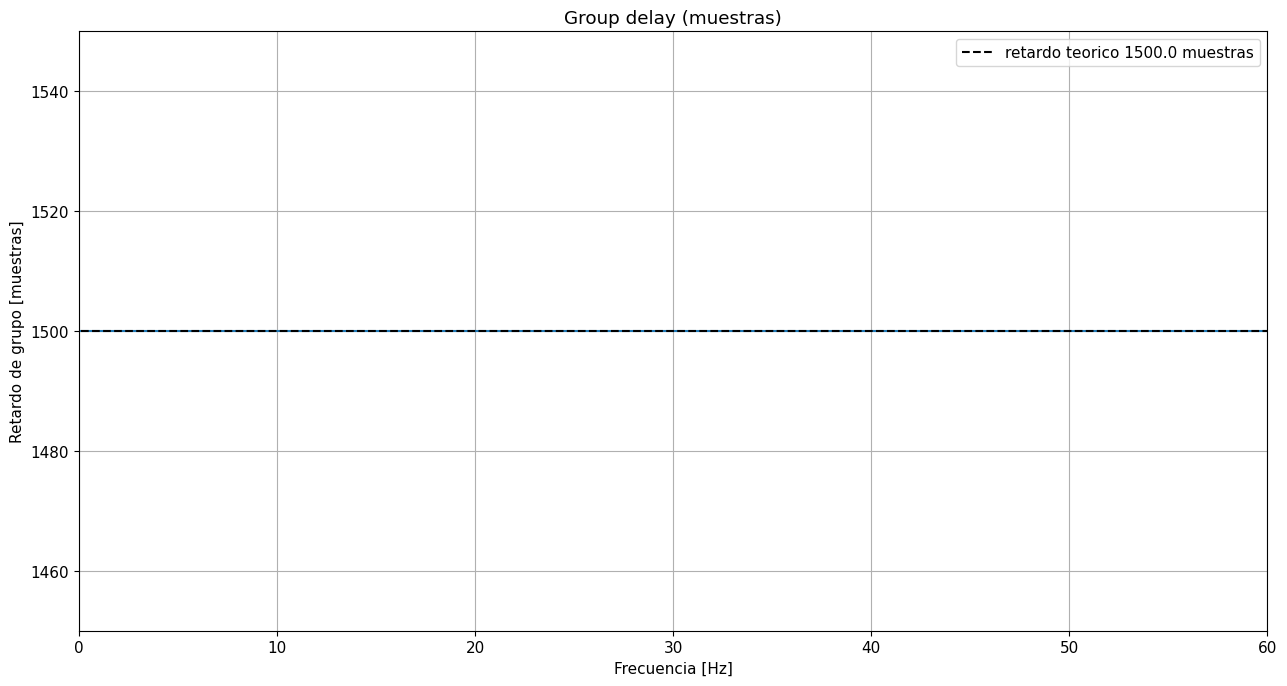

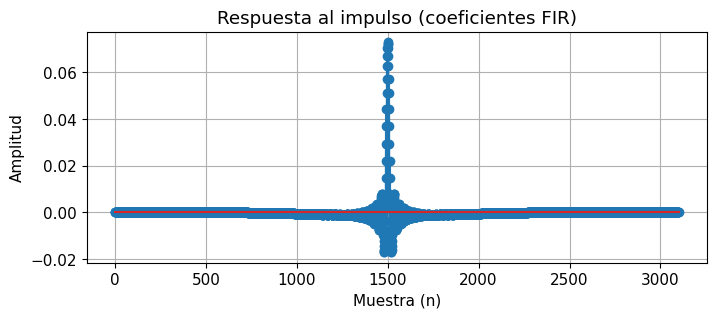

In [9]:
# plt.close('all')

# se fija una cantidad de coeficientes para la respuesta del FIR
cant_coeficientes = 3001 # 1501 default

# variables

# default: wp1=.1Hz , ws1=1Hz , wp2=35Hz , ws2=45Hz

ws1_fir = 0.1
wp1_fir = 0.5
ws2_fir = 0.7
wp2_fir = 1 
wp3_fir = 35 
ws3_fir = 39
wp4_fir = 41
ws4_fir = 45

freqs = [ws1_fir, wp1_fir, ws2_fir, wp2_fir, wp3_fir, ws3_fir, wp4_fir, ws4_fir]

frecuencias = [0, ws1_fir, wp1_fir, ws2_fir, wp2_fir, wp3_fir, ws3_fir, wp4_fir, ws4_fir, nyq_frec]

ganancia = [0, 0, 0.01, 1, 1, 1, 0.015, 0, 0, 0]

#ventana = ('chebwin', 80)

#ventana = 'bohman'

#ventana = 'blackman'

#ventana = 'cosine'

#ventana = 'taylor'

ventana = ('kaiser', 2.9)

#ventana = 'hamming'

# algoritmo de diseño, se obtienen los coeficientes del numerador
num_win = sig.firwin2(cant_coeficientes, freq = frecuencias, gain = ganancia , window= ventana , fs = fs )
# default window = 'blackmanharris' ^^

# coeficientes del denominador
den = 1.0

# muestreo el filtro donde me interesa verlo según la plantilla.
w  = np.append(np.logspace(-1, 0.8, 250), np.logspace(0.9, 1.6, 250) )
w  = np.append(w, np.linspace(110, nyq_frec, 100, endpoint=True) )

_, hh_win = sig.freqz(num_win, den, w, fs = fs)

w_gd, gd = sig.group_delay((num_win, den), w=w, fs=fs)  # gd en muestras
retardo_teorico = (cant_coeficientes - 1) / 2

mag_db = 20 * np.log10(abs(hh_win))

phase = np.angle(hh_win)
phase_unwrapped = np.unwrap(phase)

pb_idx = np.where(mag_db > -40)[0]
if pb_idx.size > 10:
    # ajustar fase_unwrapped vs frecuencia (Hz): phase = -2*pi*f*delay + const
    p = np.polyfit(w[pb_idx], phase_unwrapped[pb_idx], 1)
    slope = p[0]
    est_delay_from_phase = -slope / (2 * np.pi)   # en muestras
else:
    est_delay_from_phase = np.nan

delta = np.zeros(len(num_win) + 100)  # padding opcional
delta[0] = 1.0
h_from_filter = sig.lfilter(num_win, den, delta)  # debería coincidir con num_win (al inicio)


plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w, 20 * np.log10(abs(hh_win)), label='FIR-Win {:d}'.format(num_win.shape[0]))

plt.title('FIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([0, 60, -60, 5 ]);

axes_hdl = plt.gca()
axes_hdl.legend()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
plt.show()

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w, phase_unwrapped, label='phase unwrapped')
plt.plot(w, -2*np.pi*w*retardo_teorico, '--', label=f'lineal ideal delay {(retardo_teorico):.1f} muestras')
plt.title('Fase (rad) — desenrollada')

plt.xlim(0, min(0.5*fs, 60))
plt.ylim(-600000, 10000)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Fase [Rad]')
plt.grid()
#plt.axis([0, 60, -60, 5 ]);
plt.legend()

axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid()
_ = plt.legend()
plt.show()

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_gd, gd)
plt.hlines(retardo_teorico, xmin=w_gd.min(), xmax=w_gd.max(), colors='k',
           linestyles='--', label=f'retardo teorico {(retardo_teorico):.1f} muestras')
plt.title('Group delay (muestras)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Retardo de grupo [muestras]')

plt.xlim(0, min(0.5*fs, 60))
plt.ylim(max(0, retardo_teorico-50), retardo_teorico+50)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#axes_hdl = plt.gca()
#axes_hdl.legend()
# plt.grid()
# _ = plt.legend()

# Impulso (stem)
plt.figure(figsize=(8,3))
#plt.stem(np.arange(len(num_win)), num_win)
plt.stem(h_from_filter)

plt.title('Respuesta al impulso (coeficientes FIR)')
plt.xlabel("Muestra (n)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

## Programación del código sobre STM32-F446RE:

#### Configuración relevante del .ioc partiendo desde un proyecto base STM:

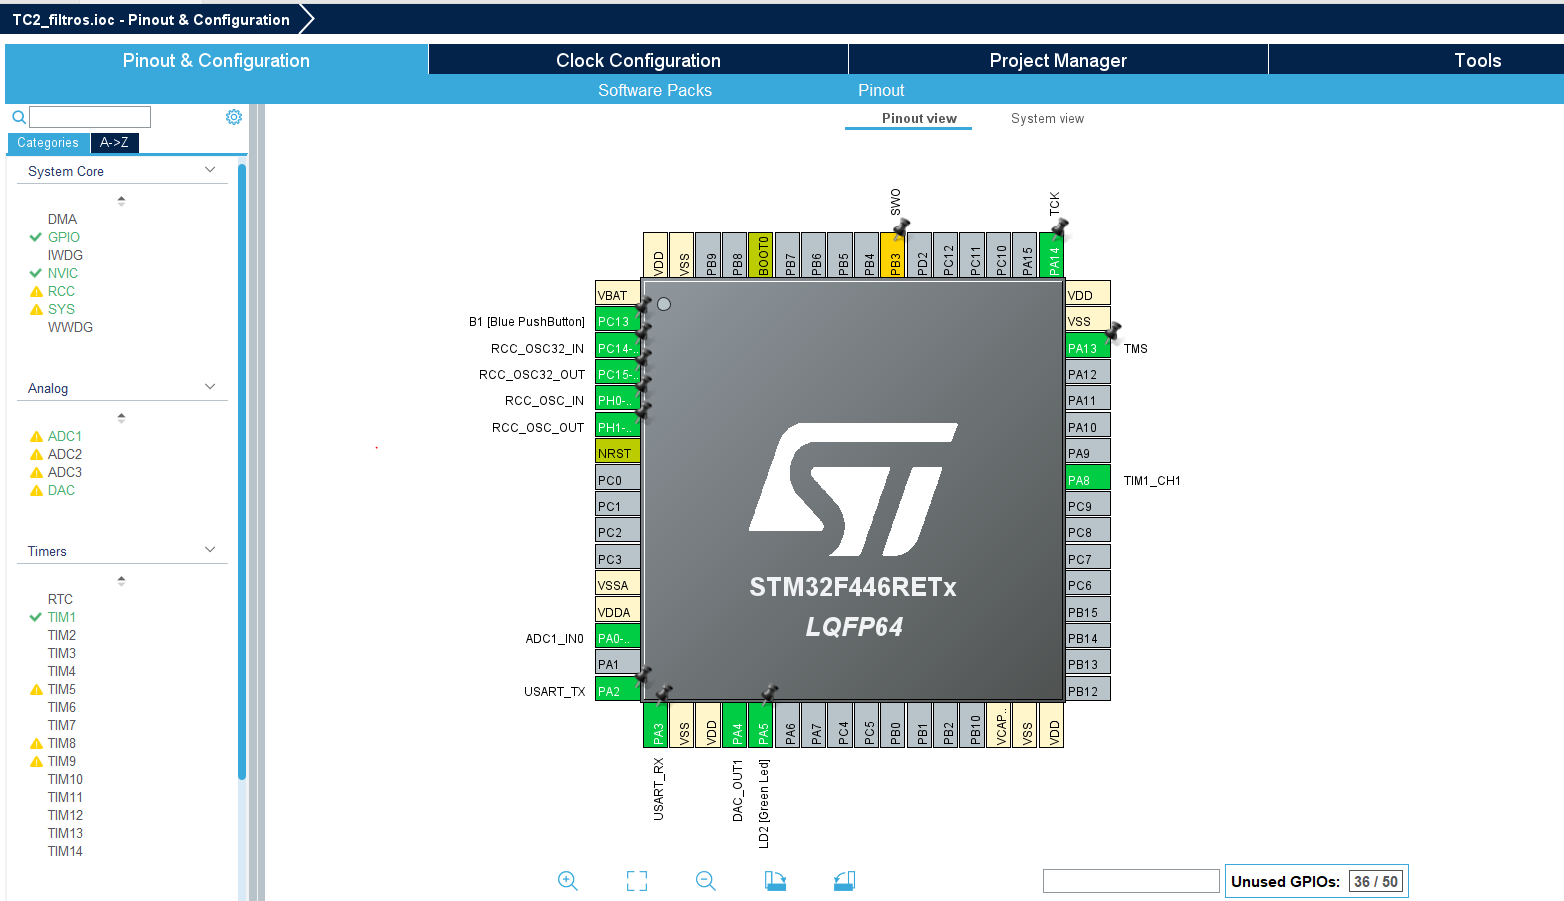
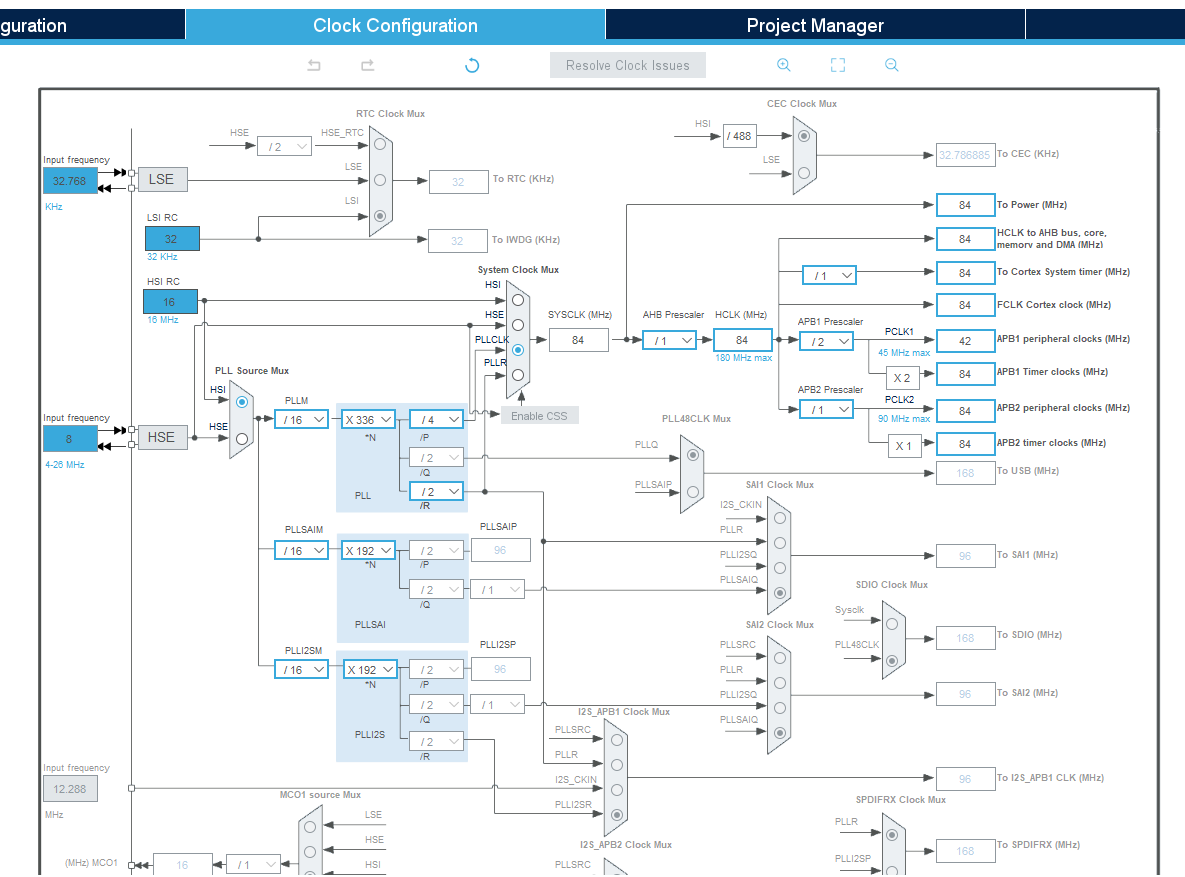

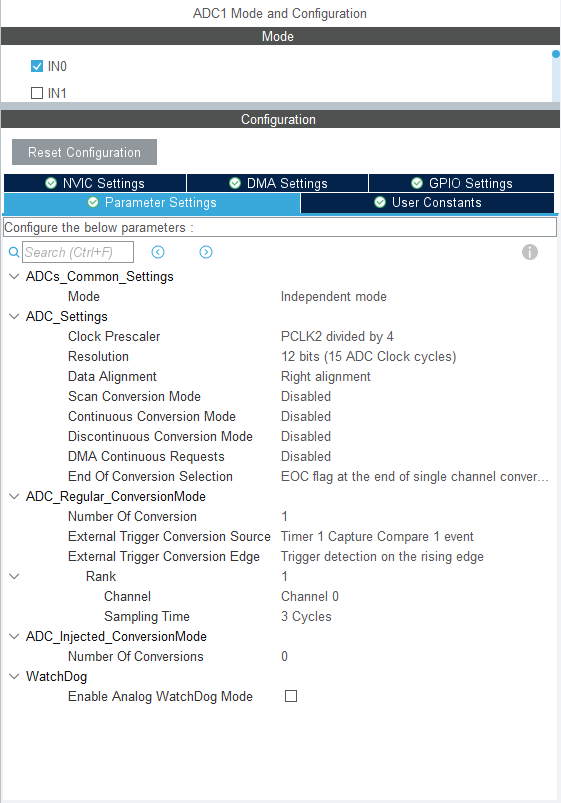
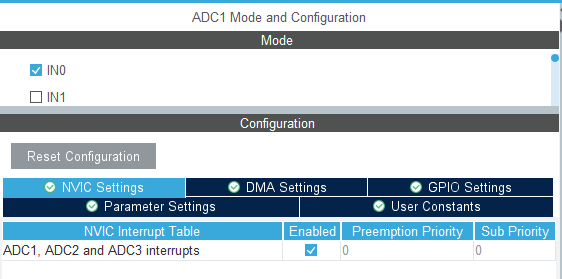
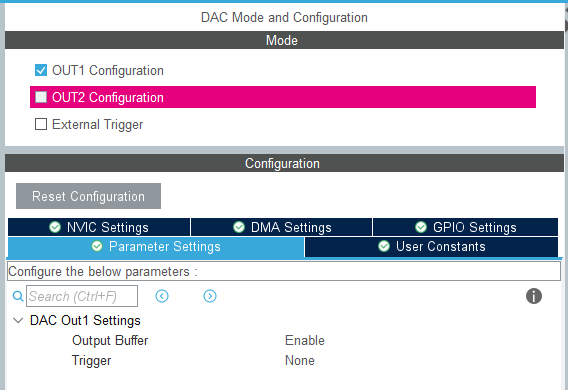
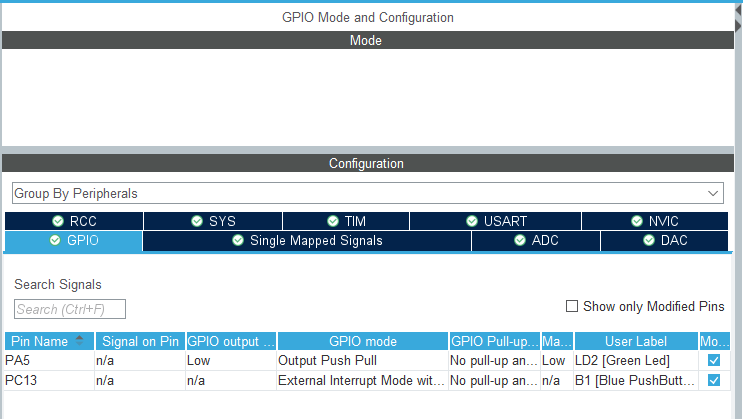
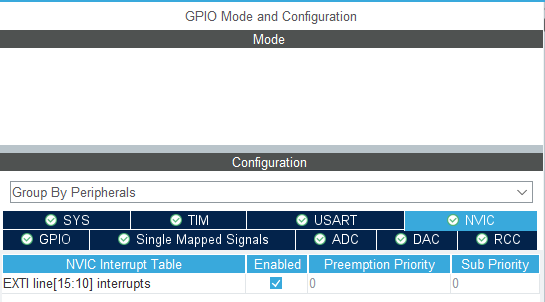
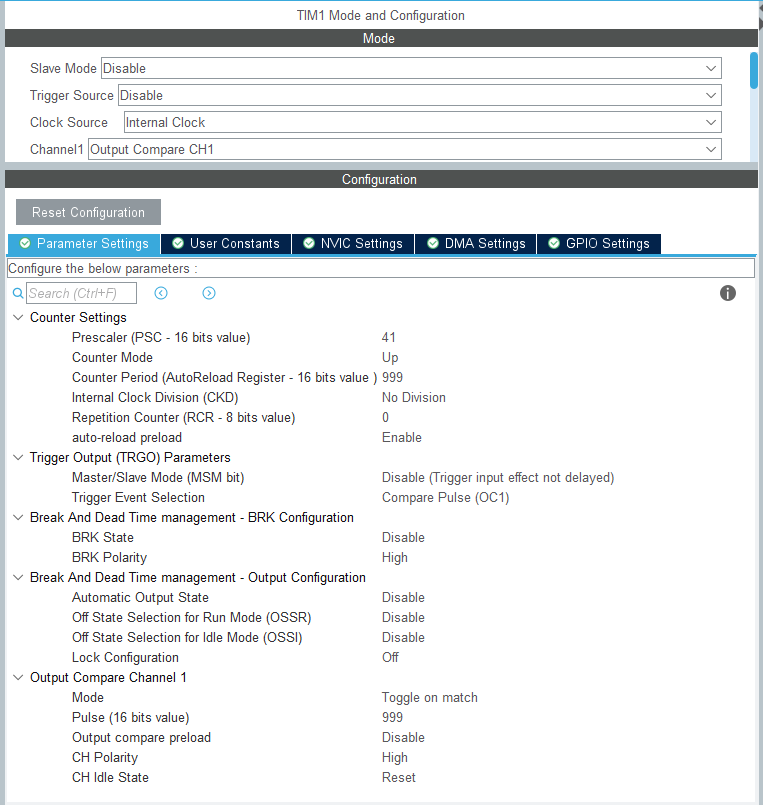

### Estructura del proyecto:

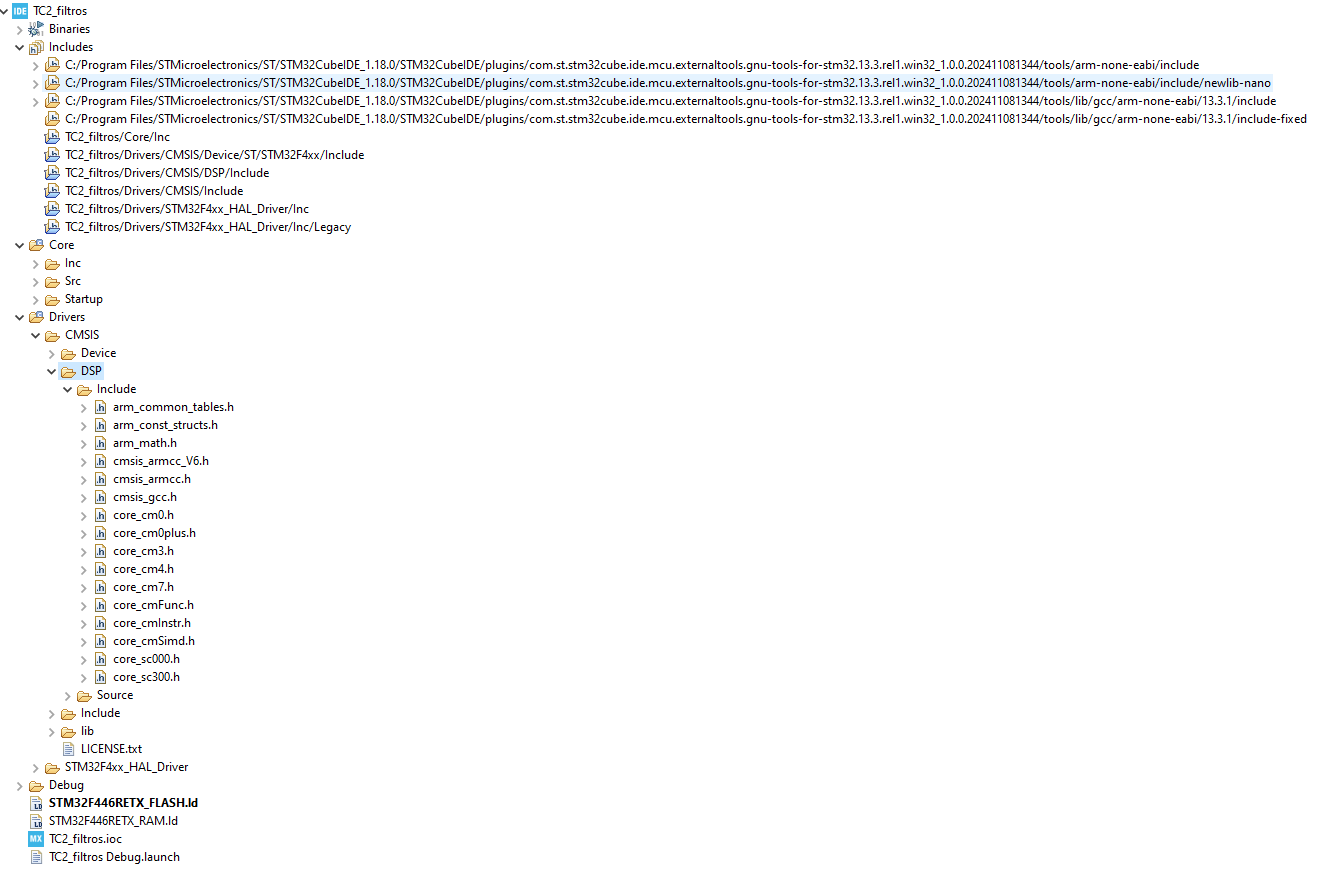

### Programa principal: Archivos y secciones relevantes
#### filter.h :

#### iir_sos_coeffs.h :

#### fir_coeffs.h :

#### En esencia lo que se hizo fue este script en python:

#### main.c , variables y loop principal:

# Laboratorio:

## Instrumentos utilizados:


- Multímetro PROSKIT MT-1217.
- Osciloscopio UNI-T GEO21L053.
- Fuente de alimentación EMakers VA150509274 y VA150509068.
- Analizador de audio Agilent U8903A.
- Generador de señales S/N 16G1051212063.


### Componentes utilizados, filtro analógico anti-aliasing:

1. Para los filtros pasabajos de entrada y salida de 20dB se utilizaron:
- Placa universal 10x10 cm
- Operacional TL082
- Capacitores de poliéster, tantalio y cerámicos de 25V
- Resistores de 1/4 Watt al 1%

#### Características eléctricas TL082, extracto de datasheet Texas Instrument (características suficientes para nuestra aplicación):
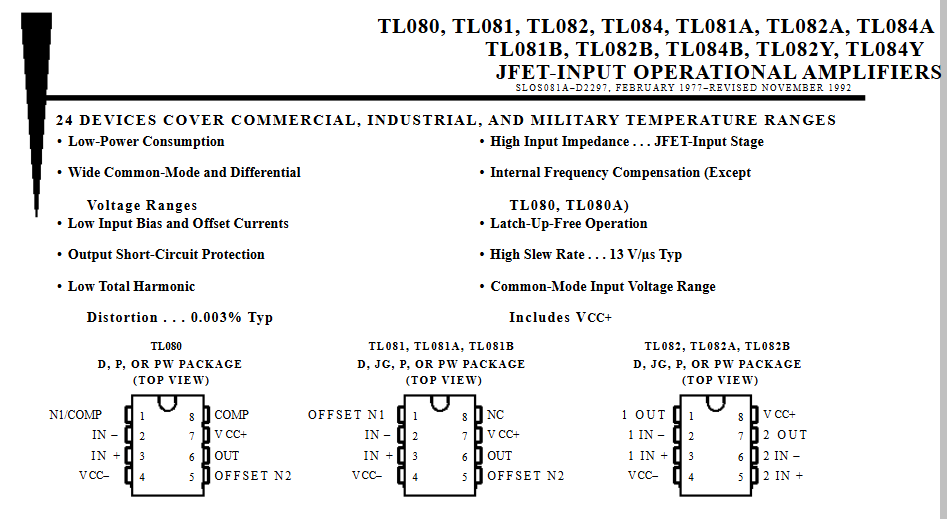
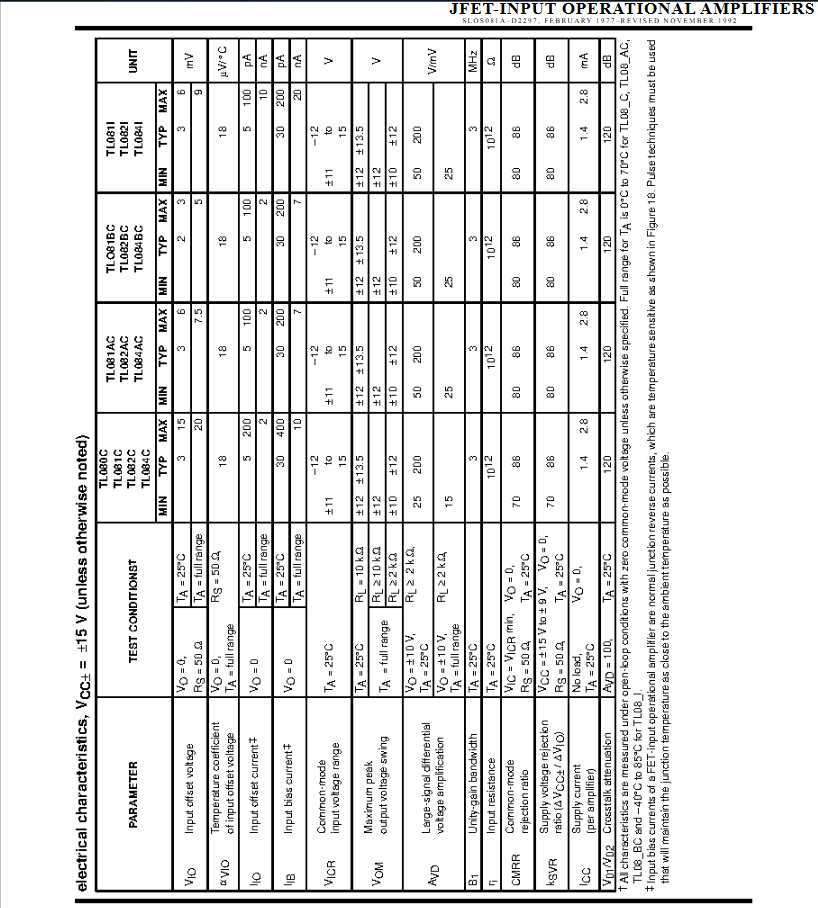

## Mediciones en laboratorio
Se obtuvieron las siguientes tablas de resultados:

### Filtro FIR:

In [15]:
import pandas as pd
pd.set_option("display.max_rows", None)   # muestra todas las filas

data= [
    [1, 	0.1,	2790,	80 ,	0.02867,	-30.85028],
    [2, 	0.2, 	2790,	140,	0.05018,	-25.98952],
    [3, 	0.3,	2790,	160,	0.05735,	-24.82968],
    [4, 	0.4,	2790,	440,	0.15771,	-16.04303],
    [5, 	0.5,	2790,	820,	0.29391,	-10.63581],
    [6, 	0.6,	2790,	1410,	0.50538,	-5.92770],
    [7, 	0.7,	2790,	1980,	0.70968,	-2.97878],
    [8, 	0.8,	2790,	2440,	0.87455,	-1.16429],
    [9, 	0.9,	2790,	2720,	0.97491,	-0.22071],
    [10,	1,  	2790,	2790,	1.00000,	0.00000],
    [11,	10, 	2790,	2790,	1.00000,	0.00000],
    [12,	15, 	2790,	2790,	1.00000,	0.00000],
    [13,	20, 	2790,	2790,	1.00000,	0.00000],
    [14,	25, 	2790,	2790,	1.00000,	0.00000],
    [15,	30, 	2790,	2790,	1.00000,	0.00000],
    [16,	35, 	2790,	2790,	1.00000,	0.00000],
    [17,	36, 	2790,	2310,	0.82796,	-1.63984],
    [18,	37, 	2790,	1650,	0.59140,	-4.56241],
    [19,	38, 	2790,	980,	0.35125,	-9.08756],
    [20,	39, 	2790,	300,	0.10753,	-19.36966],
    [21,	40, 	2790,	80, 	0.02867,	-30.85028]    
]

columns = [
    "Muestra N°",
    "Frecuencia [Hz]",
    "V_entrada [mV Vpp]",
    "V_salida [mV Vpp]",
    "Transferencia [-]",
    "Transferencia [dB]"
]

df = pd.DataFrame(data, columns=columns)
df.head(21)

,Muestra N°,Frecuencia [Hz],V_entrada [mV Vpp],V_salida [mV Vpp],Transferencia [-],Transferencia [dB]
0,1,0.1,2790,80,0.02867,-30.85028
1,2,0.2,2790,140,0.05018,-25.98952
2,3,0.3,2790,160,0.05735,-24.82968
3,4,0.4,2790,440,0.15771,-16.04303
4,5,0.5,2790,820,0.29391,-10.63581
5,6,0.6,2790,1410,0.50538,-5.92770
6,7,0.7,2790,1980,0.70968,-2.97878
7,8,0.8,2790,2440,0.87455,-1.16429
8,9,0.9,2790,2720,0.97491,-0.22071
9,10,1.0,2790,2790,1.00000,0.00000


#### Transferencia resultante práctica FIR:

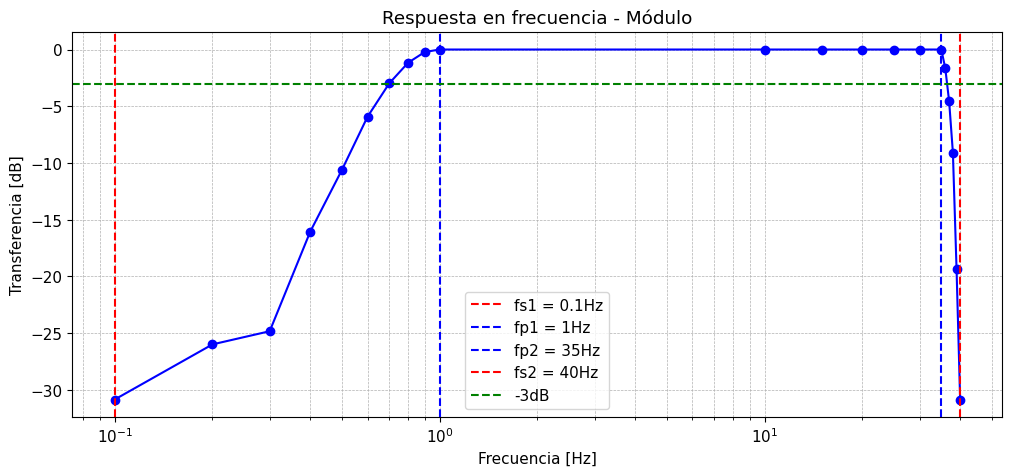

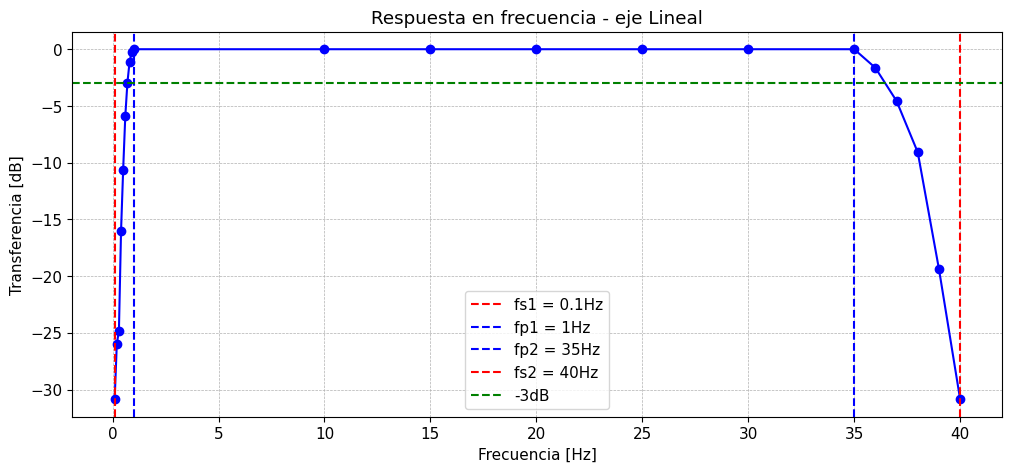

In [42]:
# --- Módulo en dB ---
plt.figure(figsize=(12,5))
plt.semilogx(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue")
plt.title("Respuesta en frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Transferencia [dB]")
plt.axvline(x=.1, color='r', linestyle='--', label='fs1 = 0.1Hz')
plt.axvline(x=1, color='b', linestyle='--', label='fp1 = 1Hz')
plt.axvline(x=35, color='b', linestyle='--', label='fp2 = 35Hz')
plt.axvline(x=40, color='r', linestyle='--', label='fs2 = 40Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

# --- Módulo con eje lineal ---
plt.figure(figsize=(12,5))
plt.plot(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue");
#plt.semilogx(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue")
plt.title("Respuesta en frecuencia - eje Lineal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Transferencia [dB]")
plt.axvline(x=.1, color='r', linestyle='--', label='fs1 = 0.1Hz')
plt.axvline(x=1, color='b', linestyle='--', label='fp1 = 1Hz')
plt.axvline(x=35, color='b', linestyle='--', label='fp2 = 35Hz')
plt.axvline(x=40, color='r', linestyle='--', label='fs2 = 40Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

### Filtro IIR:

In [53]:
data= [
    [1, 	0.1,	2790,	80 ,	0.02867,	-30.85028],
    [2, 	0.2, 	2790,	80, 	0.02867,	-30.85028],
    [3, 	0.3,	2790,	100,	0.03584,	-28.91208],
    [4, 	0.4,	2790,	80, 	0.02867,	-30.85028],
    [5, 	0.5,	2790,	80, 	0.02867,	-30.85028],
    [6, 	0.6,	2790,	80, 	0.02867,	-30.85028],
    [7, 	0.7,	2790,	80, 	0.02867,	-30.85028],
    [8, 	0.8,	2790,	80, 	0.02867,	-30.85028],
    [9, 	0.9,	2790,	240,	0.08602,	-21.30786],
    [10,	1,  	2790,	2480,	0.88889,	-1.02305],
    [11,	10, 	2790,	2790,	1.00000,	0.00000],
    [12,	15, 	2790,	2790,	1.00000,	0.00000],
    [13,	20, 	2790,	2790,	1.00000,	0.00000],
    [14,	25, 	2790,	2790,	1.00000,	0.00000],
    [15,	30, 	2790,	2790,	1.00000,	0.00000],
    [16,	35, 	2790,	2790,	1.00000,	0.00000],
    [17,	36, 	2790,	1910,	0.68459,	-3.29142],
    [18,	37, 	2790,	960,	0.34409,	-9.26666],
    [19,	38, 	2790,	500,	0.17921,	-14.93268],
    [20,	39, 	2790,	300,	0.10753,	-19.36966],
    [21,	40, 	2790,	200, 	0.07168,	-22.89148],
    [22,	41, 	2790,	160,	0.05735,	-24.82968]
]

df = pd.DataFrame(data, columns=columns)
df.head(22)

,Muestra N°,Frecuencia [Hz],V_entrada [mV Vpp],V_salida [mV Vpp],Transferencia [-],Transferencia [dB]
0,1,0.1,2790,80,0.02867,-30.85028
1,2,0.2,2790,80,0.02867,-30.85028
2,3,0.3,2790,100,0.03584,-28.91208
3,4,0.4,2790,80,0.02867,-30.85028
4,5,0.5,2790,80,0.02867,-30.85028
5,6,0.6,2790,80,0.02867,-30.85028
6,7,0.7,2790,80,0.02867,-30.85028
7,8,0.8,2790,80,0.02867,-30.85028
8,9,0.9,2790,240,0.08602,-21.30786
9,10,1.0,2790,2480,0.88889,-1.02305


#### Transferencia resultante práctica IIR:

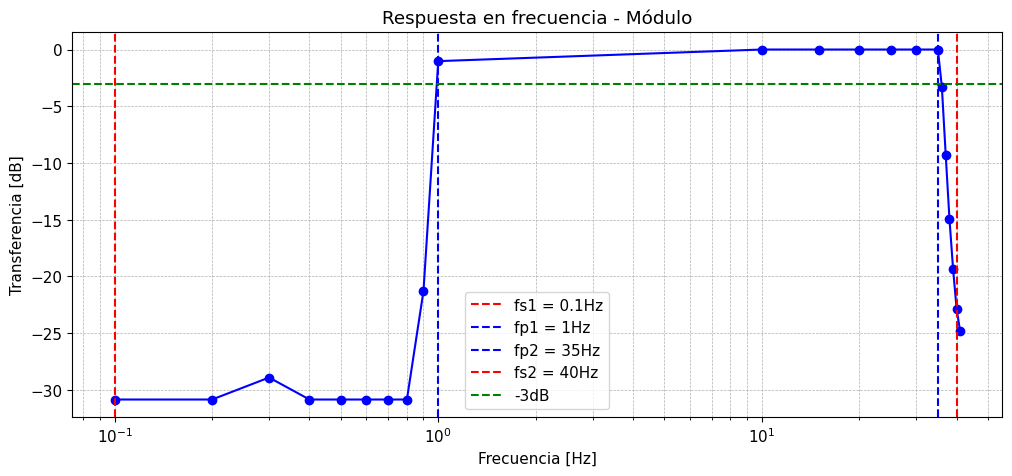

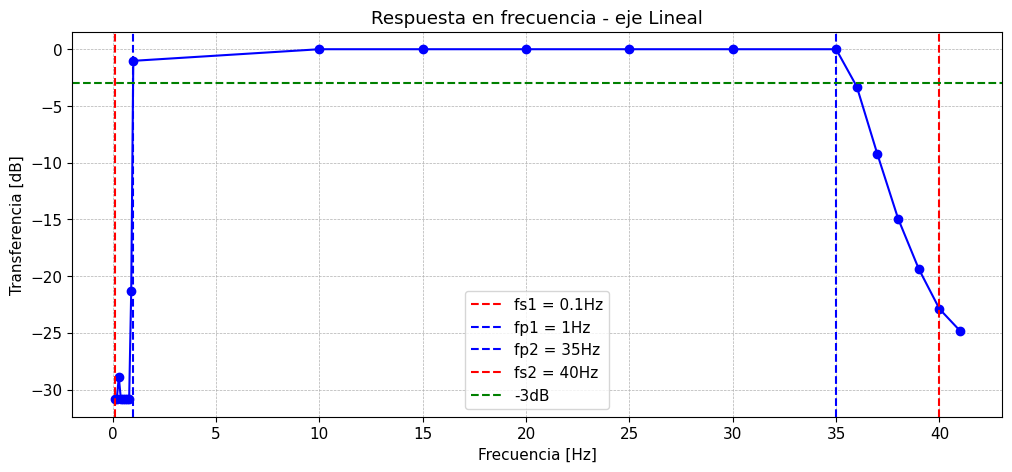

In [54]:
# --- Módulo en dB ---
plt.figure(figsize=(12,5))
plt.semilogx(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue")
plt.title("Respuesta en frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Transferencia [dB]")
plt.axvline(x=.1, color='r', linestyle='--', label='fs1 = 0.1Hz')
plt.axvline(x=1, color='b', linestyle='--', label='fp1 = 1Hz')
plt.axvline(x=35, color='b', linestyle='--', label='fp2 = 35Hz')
plt.axvline(x=40, color='r', linestyle='--', label='fs2 = 40Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

# --- Módulo con eje lineal ---
plt.figure(figsize=(12,5))
plt.plot(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue");
#plt.semilogx(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue")
plt.title("Respuesta en frecuencia - eje Lineal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Transferencia [dB]")
plt.axvline(x=.1, color='r', linestyle='--', label='fs1 = 0.1Hz')
plt.axvline(x=1, color='b', linestyle='--', label='fp1 = 1Hz')
plt.axvline(x=35, color='b', linestyle='--', label='fp2 = 35Hz')
plt.axvline(x=40, color='r', linestyle='--', label='fs2 = 40Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

#### Los valores ensayados son muy parecidos a los simulados. La plantilla se sigue correctamente. El osciloscopio tiene la limitación práctica de no poder medir más allá de -30dB.

#### Ensayo analizador de audio:

1. Para el analizador de audio se generaron 2 nuevas transferencias, FIR e IIR, que se corresponda a unas frecuencias mayores.
2. El propósito de esto era llevar la transferencia a un lugar más cómodo para el analizador de audio, ya que no se podía apreciar el análisis de hacerlo con los límites dados.

#### Nueva plantilla y filtro planteado:

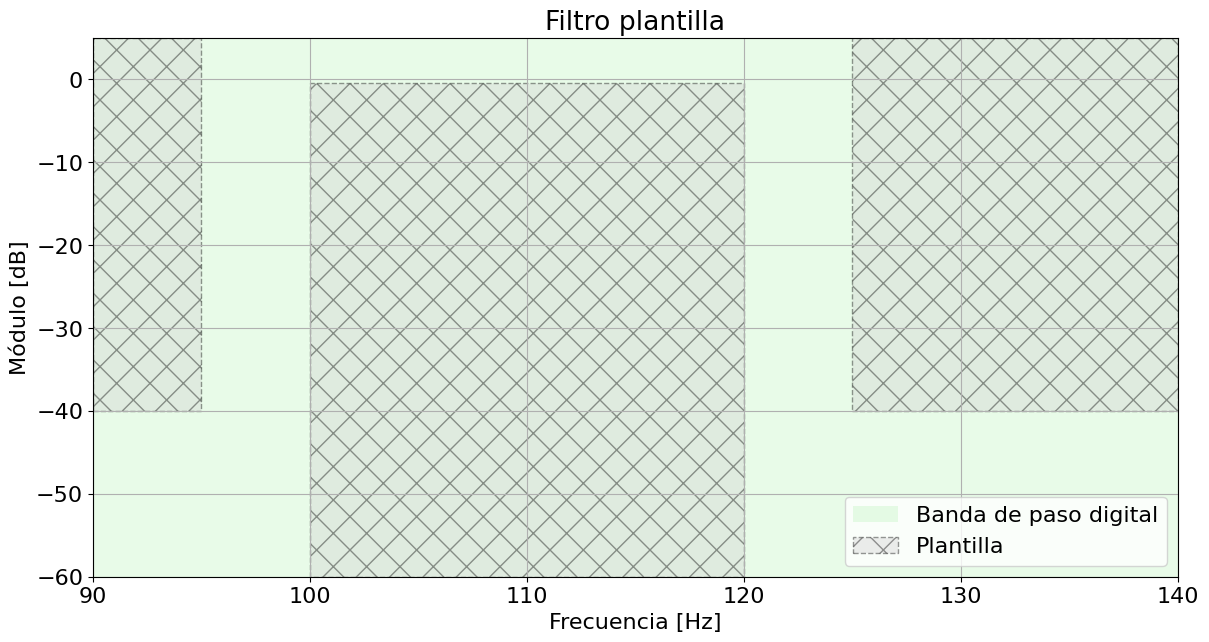

In [2]:
# Plantilla

# filter design
ripple = 0.5 # dB
atenuacion = 40 # dB

ws1 = 95 #Hz
wp1 = 100 #Hz
wp2 = 120.0 #Hz
ws2 = 125.0 #Hz

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.axis([90, 140, -60, 5 ]);

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)


plt.title('Filtro plantilla')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
_ = plt.legend()

### Filtro IIR nuevo implementado rápidamente para el testeo del analizador:

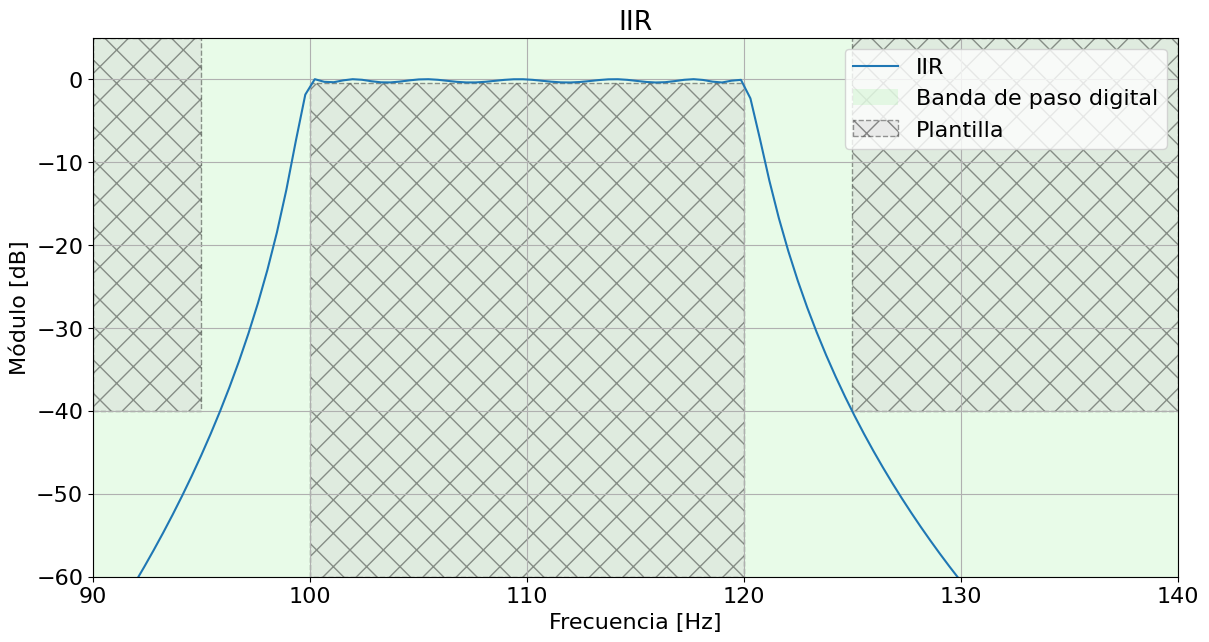

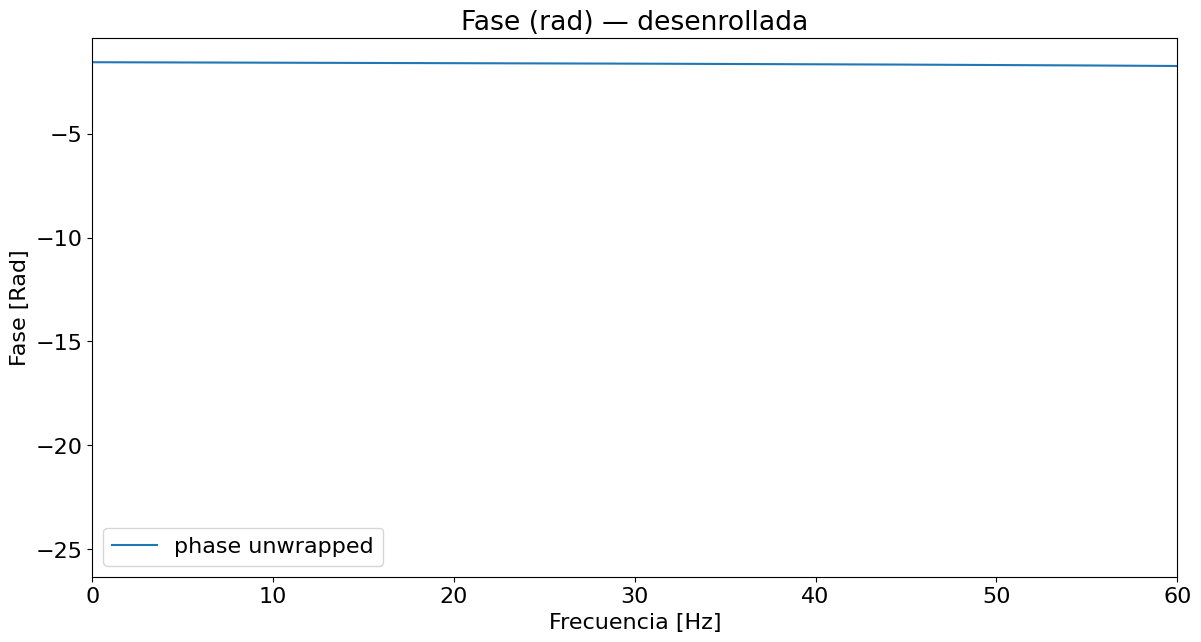

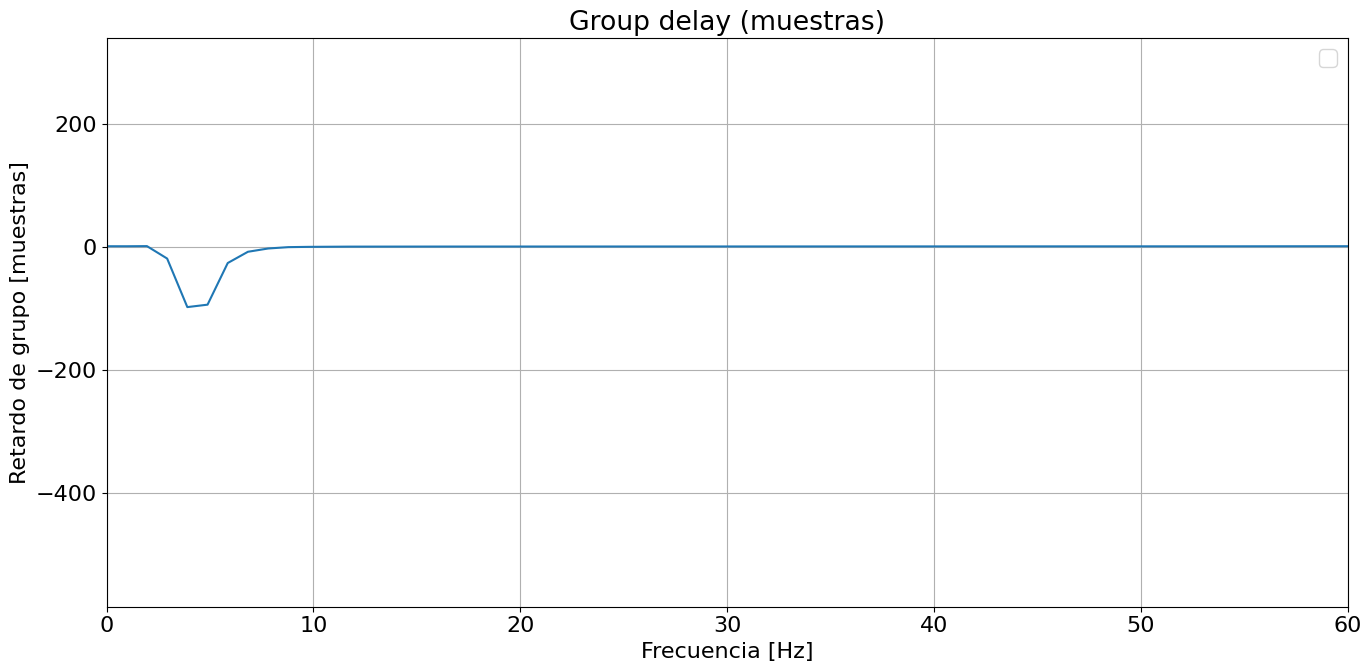

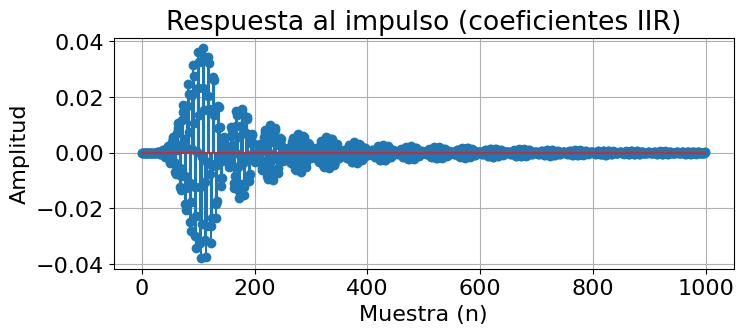

In [3]:
# Variables
ripple_iterado = 0.4 # dB
atenuacion_iterado = 40 # dB

sos_iir = sig.iirdesign(wp=[wp1,wp2],ws=[ws1,ws2],gpass=ripple_iterado, gstop=atenuacion_iterado, output='sos', analog=False, ftype='cheby1', fs = fs)

w_rad  = np.append(np.logspace(-3, 0.8, 1000), np.logspace(0.9, 1.8, 1000) )
w_rad  = np.append(w_rad, np.linspace(64, nyq_frec, 1000, endpoint=True) )

w_rad, h_iir = sig.freqz_sos(sos_iir, worN=w_rad, fs = fs)

phase = np.angle(h_iir)
phase_unwrapped = np.unwrap(phase)

#%matplotlib qt

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))

plt.plot(w_rad, 20*np.log10(np.abs(h_iir)+1e-12), label = 'IIR' )

plt.title('IIR')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Módulo [dB]')
plt.grid()
plt.axis([90, 140, -60, 5 ]);

axes_hdl = plt.gca()

plot_plantilla(filter_type = 'bandpass', fpass = (wp1, wp2), fstop =  (ws1, ws2), ripple = ripple, attenuation = atenuacion, fs = fs)
_ = axes_hdl.legend()
plt.show()

b_iir, a_iir = sig.sos2tf(sos_iir)  # convierte SOS a b, a
w_gd, gd = sig.group_delay((b_iir, a_iir), fs=fs)

mag_db = 20 * np.log10(abs(h_iir))

phase = np.angle(h_iir)
phase_unwrapped = np.unwrap(phase)

pb_idx = np.where(mag_db > -40)[0]
if pb_idx.size > 10:
    # ajustar fase_unwrapped vs frecuencia (Hz): phase = -2*pi*f*delay + const
    p = np.polyfit(w_rad[pb_idx], phase_unwrapped[pb_idx], 1)
    slope = p[0]
    est_delay_from_phase = -slope / (2 * np.pi)   # en muestras
else:
    est_delay_from_phase = np.nan

imp = np.zeros(1000)  # tamaño deseado
imp[0] = 1.0
h_iir_imp = sig.sosfilt(sos_iir, imp)

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_rad, phase_unwrapped, label='phase unwrapped')
plt.title('Fase (rad) — desenrollada')

plt.xlabel('Frecuencia [Hz]')
plt.xlim(0, min(0.5*fs, 60))
plt.ylabel('Fase [Rad]')
plt.grid()
#plt.axis([0, 60, -60, 5 ]);
plt.legend()

axes_hdl = plt.gca()
axes_hdl.legend()
plt.grid()
_ = plt.legend()
plt.show()

plt.figure(1, figsize=(fig_sz_x, fig_sz_y))
plt.plot(w_gd, gd)
plt.title('Group delay (muestras)')
plt.xlim(0, min(0.5*fs, 60))
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Retardo de grupo [muestras]')

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

#axes_hdl = plt.gca()
#axes_hdl.legend()
# plt.grid()
# _ = plt.legend()

# Impulso (stem)
plt.figure(figsize=(8,3))
plt.stem(h_iir_imp)
plt.title('Respuesta al impulso (coeficientes IIR)')
plt.xlabel("Muestra (n)")
plt.ylabel("Amplitud")
plt.grid()
plt.show()

### Resultados del nuevo filtro:

In [56]:
data = [
    [1,  18, 2790,   80,   0.02867, -30.85028],
    [2,  19, 2790,   80,   0.02867, -30.85028],
    [3,  20, 2790,   80,   0.02867, -30.85028],
    [4,  21, 2790, 2350,   0.84229,  -1.49073],
    [5,  30, 2790, 2790,   1.00000,   0.00000],
    [6,  35, 2790, 2790,   1.00000,   0.00000],
    [7,  36, 2790, 2790,   1.00000,   0.00000],
    [8,  37, 2790, 2790,   1.00000,   0.00000],
    [9,  38, 2790, 2790,   1.00000,   0.00000],
    [10, 39, 2790, 2790,   1.00000,   0.00000],
    [11, 40, 2790, 1580,   0.56631,  -4.93894],
    [12, 41, 2790, 1400,   0.50179,  -5.98952],
    [13, 42, 2790,   80,   0.02867, -30.85028],
    [14, 43, 2790,   80,   0.02867, -30.85028],
    [15, 44, 2790,   80,   0.02867, -30.85028],
    [16, 45, 2790,   80,   0.02867, -30.85028]
]
df = pd.DataFrame(data, columns=columns)
df.head(16)


,Muestra N°,Frecuencia [Hz],V_entrada [mV Vpp],V_salida [mV Vpp],Transferencia [-],Transferencia [dB]
0,1,18,2790,80,0.02867,-30.85028
1,2,19,2790,80,0.02867,-30.85028
2,3,20,2790,80,0.02867,-30.85028
3,4,21,2790,2350,0.84229,-1.49073
4,5,30,2790,2790,1.00000,0.00000
5,6,35,2790,2790,1.00000,0.00000
6,7,36,2790,2790,1.00000,0.00000
7,8,37,2790,2790,1.00000,0.00000
8,9,38,2790,2790,1.00000,0.00000
9,10,39,2790,2790,1.00000,0.00000


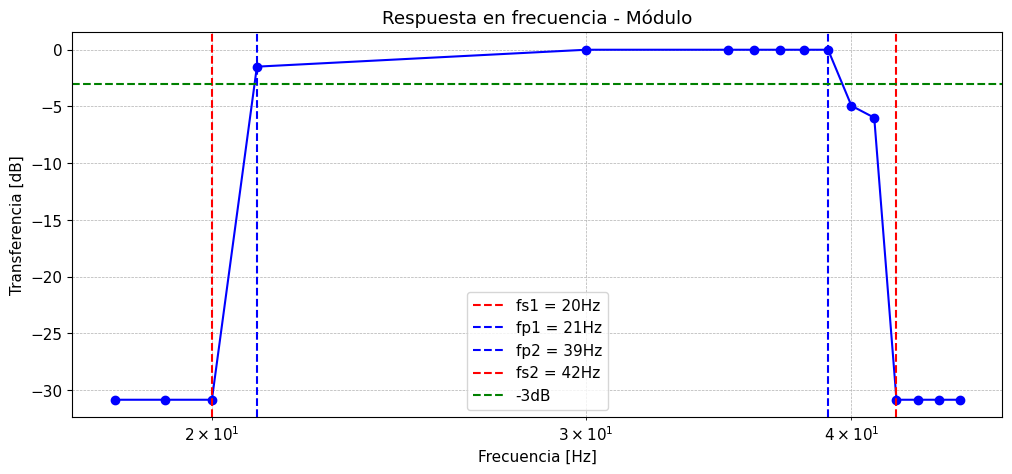

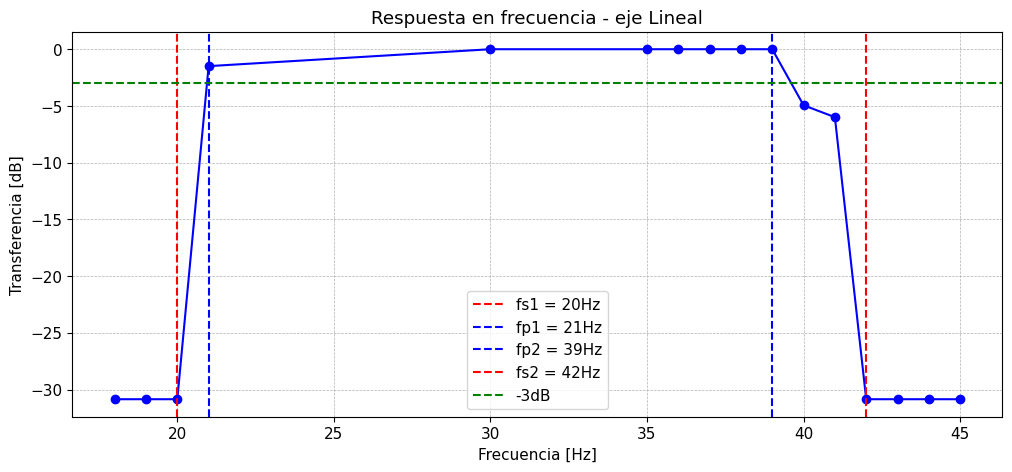

In [62]:
# --- Módulo en dB ---
plt.figure(figsize=(12,5))
plt.semilogx(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue")
plt.title("Respuesta en frecuencia - Módulo")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Transferencia [dB]")
plt.axvline(x=20, color='r', linestyle='--', label='fs1 = 20Hz')
plt.axvline(x=21, color='b', linestyle='--', label='fp1 = 21Hz')
plt.axvline(x=39, color='b', linestyle='--', label='fp2 = 39Hz')
plt.axvline(x=42, color='r', linestyle='--', label='fs2 = 42Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

# --- Módulo con eje lineal ---
plt.figure(figsize=(12,5))
plt.plot(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue");
#plt.semilogx(df["Frecuencia [Hz]"], df["Transferencia [dB]"], marker="o", linestyle="-", color="blue")
plt.title("Respuesta en frecuencia - eje Lineal")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Transferencia [dB]")
plt.axvline(x=20, color='r', linestyle='--', label='fs1 = 20Hz')
plt.axvline(x=21, color='b', linestyle='--', label='fp1 = 21Hz')
plt.axvline(x=39, color='b', linestyle='--', label='fp2 = 39Hz')
plt.axvline(x=42, color='r', linestyle='--', label='fs2 = 42Hz')
plt.axhline(y=-3, color='g', linestyle='--', label='-3dB')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.show()

- Primero hicimos las nuevas transferencias para este rango de frecuencias, pero luego se nos pidió moverlo de 100 a 120 Hz la banda de paso para darle aún más respiro al analizador.

# Respuesta Espectro:

### Filtro IIR:

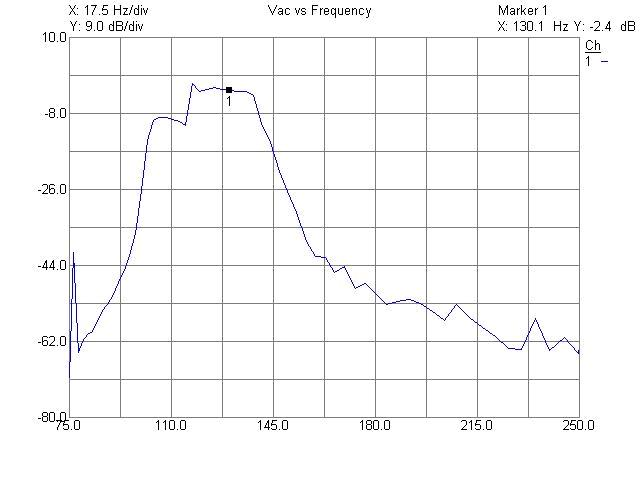

### Filtro FIR:

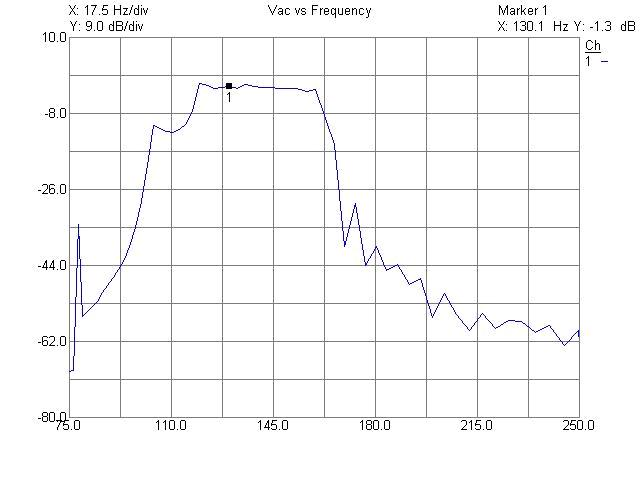

- Lamentablemente a pesar de verificar las nuevas transferencias tal como hicimos las originales antes de ensayarlas con el analizador de auido, no se pudo corroborar la transferencia con el resultado dado. El resultado estuvo corrido en frecuencia y presentaba anomalías en banda de paso y de corte, posiblemente debido a una mala configuración previa al ensayo. Sin embargo, el ancho de banda y la forma de los filtros se pueden apreciar a pesar de las irregularidades.

## Conclusiones
- Se pudo concretar la utilización del DSP del microcontrolador con éxito, pudiendo utilzar los coeficientes generados en la simulación y verificando su correcto funcionamiento.
- Los errores pueden deberse principalmente a error de método al momento de tomar las mediciones, ya que el nivel de similitud es muy aceptable.
- El analizador de audio muestra una transferencia diferente a la simulada, donde nosotros atribuímos estos errores mayormente a error de método. De todas maneras se puede apreciar el comportamiento esperado con un ancho de banda similar.